# Kendall-tau inflation correction — FRESH cohort re-run (gen9, bio1)

`pool_raw` (current, inflated) vs `pool_gc` (genomic control, keeps resolution) vs
`site_gc` (site-collapsed 31 + GC) vs `msr` (structure-preserving null, floored).
Settled decision: keep Kendall raw (honest corrections flatten the pseudoreplicated
peaks), trust LFMM — re-checked here on the re-estimated cohort.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2

GNP = "/global/scratch/users/tbellg/kmate/analysis/grenenet_gea/gea_newpanel/results"
OUT = f"{GNP}/kendall_fix_test_fresh"; import os; os.makedirs(OUT, exist_ok=True)
CLASSES = ["snp", "nonsnp"]
METHODS = ["pool_raw", "pool_gc", "site_gc", "msr"]
LABEL = {"pool_raw": "pool-level RAW (current)", "pool_gc": "pool + genomic control",
         "site_gc": "site-collapsed (31) + GC", "msr": "MSR structure-null (floored)"}
COLORS = {"pool_raw": "#7f7f7f", "pool_gc": "#1f77b4", "site_gc": "#2ca02c", "msr": "#d62728"}
CHROMS = [f"Chr{i}" for i in range(1, 6)]; Q_FLOOR = 1e-16; NULLMED = chi2.ppf(0.5, 1)

def gif(p):
    p = np.asarray(p, float); p = p[np.isfinite(p) & (p > 0)]
    return float(np.median(chi2.isf(p, 1)) / NULLMED)
def gc_calibrate(p, lam):
    x2 = chi2.isf(np.clip(np.asarray(p, float), 1e-300, 1), 1); return chi2.sf(x2 / lam, 1)
def _load(path):
    d = pd.read_csv(path, usecols=["chrom", "pos", "MAF", "pval"])
    d = d[(d.MAF >= 0.05) & d.chrom.astype(str).isin(CHROMS) & d.pval.notna() & (d.pval > 0)].copy()
    d["chrom"] = d["chrom"].astype(str); return d

_POOL = {c: _load(f"{GNP}/kendall/kendall_{c}_gen9_bio1.csv") for c in CLASSES}
_SITE = {c: _load(f"{GNP}/kendall_site/kendall_{c}_site_bio1.csv") for c in CLASSES}

def load(method, cls):
    if method == "pool_raw":
        return _POOL[cls][["chrom", "pos", "pval"]].copy()
    if method == "pool_gc":
        d = _POOL[cls].copy(); d["pval"] = gc_calibrate(d["pval"].to_numpy(), gif(d["pval"])); return d[["chrom", "pos", "pval"]]
    if method == "site_gc":
        d = _SITE[cls].copy(); d["pval"] = gc_calibrate(d["pval"].to_numpy(), gif(d["pval"])); return d[["chrom", "pos", "pval"]]
    if method == "msr":
        z = np.load(f"{GNP}/msr_kendall/msr_arrays_{cls}_bio1.npz")
        d = pd.DataFrame({"chrom": z["chrom"].astype(str), "pos": z["pos"].astype(np.int64), "pval": z["p_msr"]})
        return d[d.chrom.isin(CHROMS) & d.pval.notna() & (d.pval > 0)].copy()

def bh_count_crit(p, q=0.05):
    v = np.sort(np.asarray(p, float)); m = len(v)
    ok = v <= q * np.arange(1, m + 1) / m
    k = int(np.flatnonzero(ok).max() + 1) if ok.any() else 0
    return k, (q * k / m if k else np.nan)

allpos = pd.concat([_POOL[c][["chrom", "pos"]] for c in CLASSES])
chrom_max = allpos.groupby("chrom")["pos"].max().reindex(CHROMS).fillna(0)
GAP = 5e6; offset, off = {}, 0.0
for c in CHROMS: offset[c] = off; off += chrom_max[c] + GAP
ticks = [offset[c] + chrom_max[c] / 2 for c in CHROMS]
chrom_col = {c: ("#3b6fb0" if i % 2 == 0 else "#9bbce0") for i, c in enumerate(CHROMS)}
print("GIF:", {(m, c): round(gif(load(m, c)["pval"]), 2) for m in METHODS for c in CLASSES})

GIF: {('pool_raw', 'snp'): 9.57, ('pool_raw', 'nonsnp'): 9.48, ('pool_gc', 'snp'): 1.0, ('pool_gc', 'nonsnp'): 1.0, ('site_gc', 'snp'): 1.0, ('site_gc', 'nonsnp'): 1.0, ('msr', 'snp'): 1.18, ('msr', 'nonsnp'): 1.23}


## QQ plot (raw per-record p, calibration)

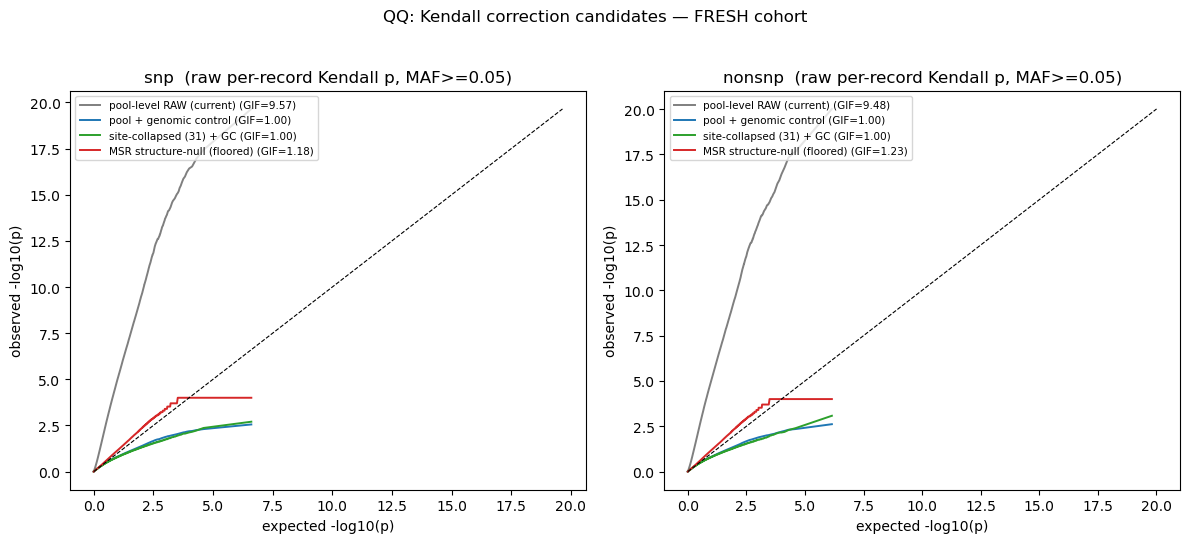

In [2]:
def qq_points(p, maxn=40000):
    p = np.sort(np.asarray(p, float)); p = p[np.isfinite(p) & (p > 0)]; n = len(p)
    exp = -np.log10((np.arange(1, n + 1) - 0.5) / n); obs = -np.log10(np.clip(p, 1e-320, 1))
    if n > maxn:
        idx = np.unique(np.r_[np.linspace(0, n - 1, maxn).astype(int), np.arange(n - 300, n)])
        exp, obs = exp[idx], obs[idx]
    return exp, obs
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, cls in zip(axes, CLASSES):
    mx = 0
    for m in METHODS:
        p = load(m, cls)["pval"].to_numpy(); ex, ob = qq_points(p)
        ax.plot(ex, ob, color=COLORS[m], lw=1.4, label=f"{LABEL[m]} (GIF={gif(p):.2f})")
        mx = max(mx, ex.max(), ob.max())
    ax.plot([0, mx], [0, mx], "k--", lw=0.8)
    ax.set_xlabel("expected -log10(p)"); ax.set_ylabel("observed -log10(p)")
    ax.set_title(f"{cls}  (raw per-record Kendall p, MAF>=0.05)"); ax.legend(fontsize=7.5, loc="upper left")
fig.suptitle("QQ: Kendall correction candidates — FRESH cohort", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95]); fig.savefig(f"{OUT}/qq_kendall_fixcompare_fresh.png", dpi=140, bbox_inches="tight"); plt.show()

## Raw per-record Manhattan (pre-WZA)

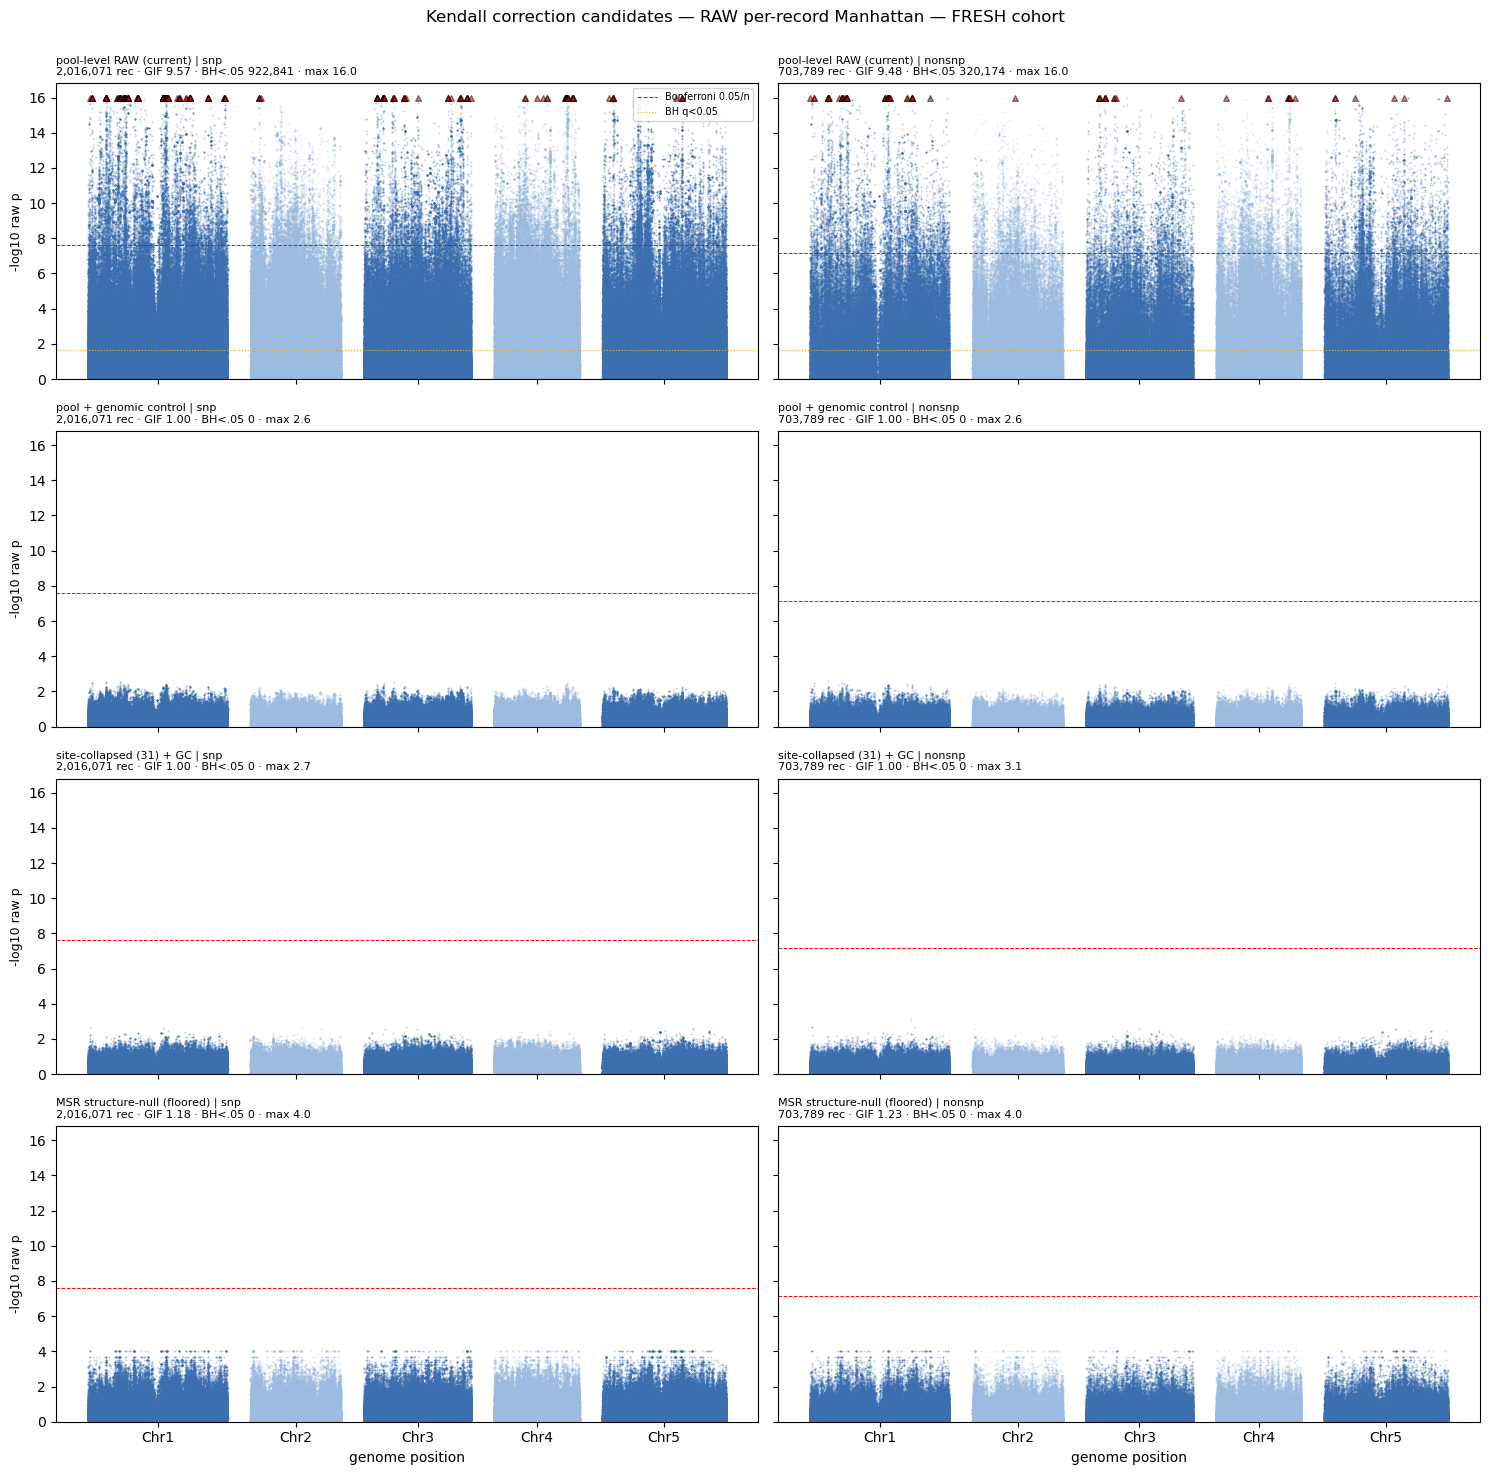

In [3]:
RAW_YMAX = -np.log10(Q_FLOOR)
fig, axes = plt.subplots(len(METHODS), len(CLASSES), figsize=(15, 15), sharex=True, sharey=True)
for r, m in enumerate(METHODS):
    for cc, cls in enumerate(CLASSES):
        ax = axes[r, cc]; d = load(m, cls).copy(); d["x"] = d["pos"] + d["chrom"].map(offset)
        d["mlogp"] = -np.log10(d["pval"].clip(lower=Q_FLOOR)); n = len(d)
        ofs = d["pval"] < Q_FLOOR
        for c in CHROMS:
            mm = (d["chrom"] == c) & ~ofs
            ax.scatter(d["x"][mm], d["mlogp"][mm].clip(upper=RAW_YMAX), s=2, c=chrom_col[c], alpha=.3, linewidths=0, rasterized=True)
        if ofs.any():
            ax.scatter(d["x"][ofs], np.full(int(ofs.sum()), RAW_YMAX), marker="^", s=16, color="red", edgecolor="k", zorder=6, alpha=.5)
        bonf = 0.05 / n; ax.axhline(-np.log10(bonf), color="red", lw=0.7, ls="--")
        nbh, crit = bh_count_crit(d["pval"].to_numpy())
        if nbh: ax.axhline(-np.log10(crit), color="orange", lw=0.8, ls=":")
        ax.set_title(f"{LABEL[m]} | {cls}\n{n:,} rec · GIF {gif(d['pval']):.2f} · BH<.05 {nbh:,} · max {d['mlogp'].max():.1f}", fontsize=8, loc="left")
        if cc == 0: ax.set_ylabel("-log10 raw p", fontsize=9)
        ax.set_ylim(0, RAW_YMAX + 0.8)
for ax in axes[-1, :]:
    ax.set_xticks(ticks); ax.set_xticklabels(CHROMS); ax.set_xlabel("genome position")
axes[0, 0].plot([], [], color="red", ls="--", lw=0.8, label="Bonferroni 0.05/n")
axes[0, 0].plot([], [], color="orange", ls=":", lw=0.8, label="BH q<0.05")
axes[0, 0].legend(fontsize=7, loc="upper right")
fig.suptitle("Kendall correction candidates — RAW per-record Manhattan — FRESH cohort", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.98]); fig.savefig(f"{OUT}/manhattan_raw_kendall_fixcompare_fresh.png", dpi=130, bbox_inches="tight"); plt.show()

## Summary (GIF, frac p<.05, per-record BH, max peak)

In [4]:
rows = []
for m in METHODS:
    for cls in CLASSES:
        d = load(m, cls); p = d["pval"].to_numpy(); nbh, _ = bh_count_crit(p)
        rows.append(dict(method=m, cls=cls, n=len(d), gif=round(gif(p), 2),
                         frac_p05=round(float((p < 0.05).mean()), 3),
                         min_p=float(np.nanmin(p)), max_mlogp=round(float(-np.log10(np.nanmin(p))), 1), n_bh_perrec=nbh))
summary = pd.DataFrame(rows); summary.to_csv(f"{OUT}/kendall_fixcompare_fresh_summary.csv", index=False)
print(summary.to_string(index=False)); summary

  method    cls       n  gif  frac_p05        min_p  max_mlogp  n_bh_perrec
pool_raw    snp 2016071 9.57     0.529 2.249739e-20       19.6       922841
pool_raw nonsnp  703789 9.48     0.526 9.883188e-21       20.0       320174
 pool_gc    snp 2016071 1.00     0.014 2.793895e-03        2.6            0
 pool_gc nonsnp  703789 1.00     0.014 2.426717e-03        2.6            0
 site_gc    snp 2016071 1.00     0.011 1.984643e-03        2.7            0
 site_gc nonsnp  703789 1.00     0.011 8.328848e-04        3.1            0
     msr    snp 2016071 1.18     0.075 9.999000e-05        4.0            0
     msr nonsnp  703789 1.23     0.078 9.999000e-05        4.0            0


,method,cls,n,gif,frac_p05,min_p,max_mlogp,n_bh_perrec
0,pool_raw,snp,2016071,9.57,0.529,2.249739e-20,19.6,922841
1,pool_raw,nonsnp,703789,9.48,0.526,9.883188e-21,20.0,320174
2,pool_gc,snp,2016071,1.00,0.014,2.793895e-03,2.6,0
3,pool_gc,nonsnp,703789,1.00,0.014,2.426717e-03,2.6,0
4,site_gc,snp,2016071,1.00,0.011,1.984643e-03,2.7,0
5,site_gc,nonsnp,703789,1.00,0.011,8.328848e-04,3.1,0
6,msr,snp,2016071,1.18,0.075,9.999000e-05,4.0,0
7,msr,nonsnp,703789,1.23,0.078,9.999000e-05,4.0,0
